### Load essential modules

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eunpyohong/fruit-object-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/eunpyohong/fruit-object-detection


In [2]:
import os
import io
import requests
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image

In [3]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!ls $path/fruit

train  valid


In [5]:
classes = ['Apple','Orange','Pear','Watermelon','Durian','Lemon','Grape','Pineapple','Dragon Fruit','Melon', 'Cantaloupe']
epochs = 15

#### Create **data.yaml** for **YOLO**

In [6]:
def create_yaml(root: str, train: str, valid: str, classes: list):
  """ Create dataset.yaml """
  nc = len(classes)
  content = f"""
path: {root}
train: {train}
val: {valid}

nc: {nc}
names: {classes}
  """
  with open("dataset.yaml", "w") as f:
      f.write(content)
  print("Created dataset.yaml!")

In [7]:
create_yaml(path, "fruit/train", "fruit/valid", classes)

Created dataset.yaml!


In [8]:
model = YOLO("yolo26n.pt")

#### Train the model

In [9]:
model.train(data="dataset.yaml", epochs=epochs, batch=8, device=[0, 1])

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False

#### Get the best weights after training and test


0: 320x320 13 Lemons, 16.9ms
1: 320x320 1 Grape, 16.9ms
2: 320x320 1 Cantaloupe, 16.9ms
3: 320x320 3 Melons, 16.9ms
Speed: 1.6ms preprocess, 16.9ms inference, 6.7ms postprocess per image at shape (1, 3, 320, 320)


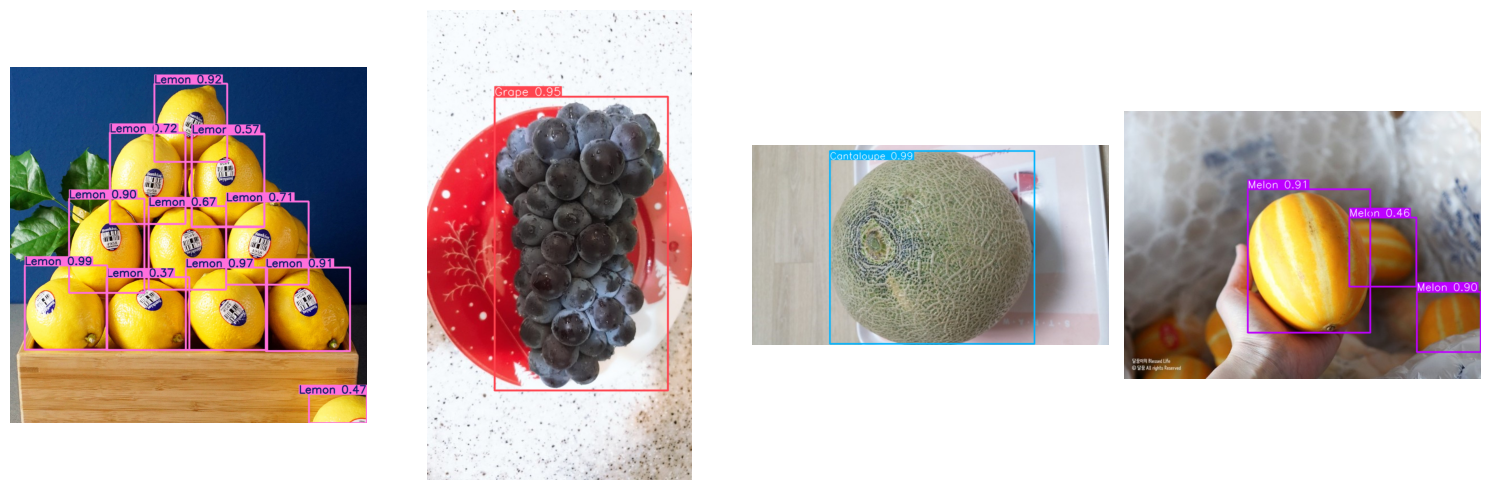

In [10]:
best_model = YOLO("runs/detect/train/weights/best.pt")

results = best_model.predict(glob(f"{path}/fruit/valid/images/*.jpg")[-4:], imgsz=320)

# Create subplots
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for ax, result in zip(axes, results):
    img = result.plot()  # get annotated image (numpy array)
    ax.imshow(img[:, :, ::-1]) # convert BGR to RGB
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
urls = [
    "https://upload.wikimedia.org/wikipedia/commons/c/cb/Pineapple_and_cross_section.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/e/e7/Cantaloupe_and_canary_melon.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/Taiwan_2009_Tainan_City_Organic_Farm_Watermelon_FRD_7962.jpg/500px-Taiwan_2009_Tainan_City_Organic_Farm_Watermelon_FRD_7962.jpg"
]
headers = {
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36"
}

imgs = [requests.get(url, headers=headers).content for url in urls]
wiki_images = []
for content in imgs:
    try:
        img = Image.open(io.BytesIO(content))
        wiki_images.append(img)
    except Exception as e:
        print(f"Failed to open image: {e}")


0: 320x320 1 Pineapple, 21.4ms
1: 320x320 2 Lemons, 21.4ms
2: 320x320 1 Watermelon, 21.4ms
Speed: 1.0ms preprocess, 21.4ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 320)


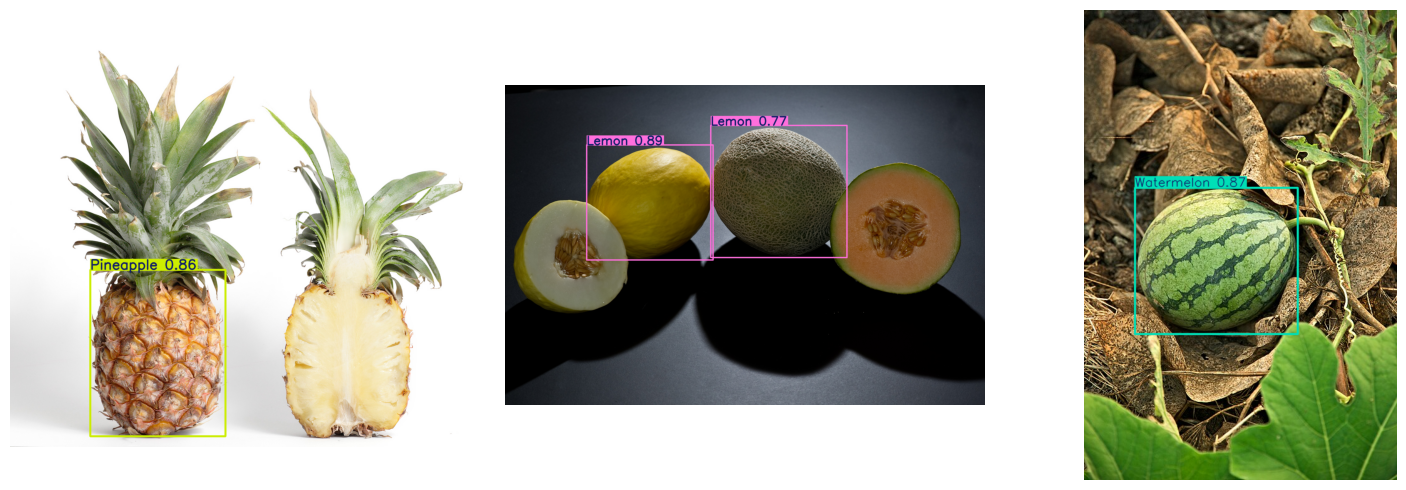

In [12]:
results = best_model.predict(wiki_images, imgsz=320)

# Create subplots
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for ax, result in zip(axes, results):
    img = result.plot()  # get annotated image (numpy array)
    ax.imshow(img[:, :, ::-1]) # BGR -> RGB
    ax.axis("off")

plt.tight_layout()
plt.show()